## 2026_Winter_DL_week5_Homework
CNN 실습 예제코드입니다!

이번 5주차 숙제는 총 2가지로 구성되어 있습니다.
- 논문 리뷰 - ResNet : https://arxiv.org/abs/1512.03385
    - 다음 논문을 읽고 팀별로 논문 스터디 및 정리를 준비해주시면 됩니다! (notion 이나 ppt 로 논문 정리 자료 제작 후에 팀별로 git에 업로드 해주세요 :D)

- 코드 과제 (아래 두 가지 중 택1!)
    - 1) (CNN 을 처음 접해보시거나 기초를 더 다지고 싶은 분들께 추천)
        - 아래 실습코드를 그대로 참고하셔도 좋고, 새롭게 짜셔도 좋습니다. 데이터셋은 CIFAR10이 아닌 벤치마크(MNIST, FFHQ, ImageNet)이나 다른 데이터셋을 사용하되, 학습 시간 및 리소스를 적절히 사용할 수 있는 화질을 사용하는 것을 추천 드립니다. 또한, 앞서 배운 regularization, initialization, optimizer 등등 기법을 추가해보시거나, layer를 변형하는 시도를 추가하여 결과를 분석해주세요.
        - example : Earlystopping 추가, Dropoutlayer 추가, batch nomalization 추가, stride 및 padding 변형, Conv layer 추가 및 삭제 등등
    - 2) (이미 CNN 지식이 있는 분들)
        - ResNet 을 논문 "**만**" 읽고 핵심 모듈 코드를 직접 짜보세요! 코드를 보지 않고 conv block이나 layer들을 논문 기반으로 짜보시면 됩니다.(임교수님께서 추천해주신 공부법입니다 ㅎㅎ)

In [1]:
# =============================================================================
# [통합 코드] 환경 설정 + 데이터 로드 + 정확도 향상 학습 (All-in-One)
# =============================================================================

import os
import urllib.request
import gzip
import numpy as np
import matplotlib.pyplot as plt

In [2]:
# -----------------------------------------------------------------------------
# 1. 필수 라이브러리 및 소스코드 다운로드 (ModuleNotFoundError 해결)
# -----------------------------------------------------------------------------
base_url = "https://raw.githubusercontent.com/WegraLee/deep-learning-from-scratch/master/"
files = {
    "dataset/mnist.py": "dataset/mnist.py",
    "common/functions.py": "common/functions.py",
    "common/gradient.py": "common/gradient.py",
    "common/layers.py": "common/layers.py",
    "common/multi_layer_net_extend.py": "common/multi_layer_net_extend.py",
    "common/optimizer.py": "common/optimizer.py",
    "common/util.py": "common/util.py"
}

print("1. 필수 소스코드 다운로드 중...")
for remote, local in files.items():
    if not os.path.exists(os.path.dirname(local)):
        os.makedirs(os.path.dirname(local))
    if not os.path.exists(local):
        urllib.request.urlretrieve(base_url + remote, local)
print("   완료!")

1. 필수 소스코드 다운로드 중...
   완료!


In [3]:
# -----------------------------------------------------------------------------
# 2. MNIST 데이터 수동 다운로드 (HTTP 404 에러 방지)
# -----------------------------------------------------------------------------
url_base = 'https://ossci-datasets.s3.amazonaws.com/mnist/'
key_file = {
    'train_img': 'train-images-idx3-ubyte.gz',
    'train_label': 'train-labels-idx1-ubyte.gz',
    'test_img': 't10k-images-idx3-ubyte.gz',
    'test_label': 't10k-labels-idx1-ubyte.gz'
}

print("2. MNIST 데이터 파일 다운로드 중...")
dataset_dir = 'dataset'
if not os.path.exists(dataset_dir):
    os.mkdir(dataset_dir)

for v in key_file.values():
    file_path = dataset_dir + '/' + v
    if not os.path.exists(file_path):
        try:
            urllib.request.urlretrieve(url_base + v, file_path)
        except Exception as e:
            print(f'   다운로드 실패: {v} - {e}')
print("   완료!")


2. MNIST 데이터 파일 다운로드 중...
   완료!


In [4]:
# -----------------------------------------------------------------------------
# 3. 데이터 로드 및 학습 시작 (정확도 향상 설정 적용)
# -----------------------------------------------------------------------------
from dataset.mnist import load_mnist
from common.multi_layer_net_extend import MultiLayerNetExtend
from common.optimizer import Adam

print("3. 데이터 로드 및 전처리 중...")
# 전체 데이터 사용 (60,000개)
(x_train, t_train), (x_test, t_test) = load_mnist(normalize=True, flatten=True, one_hot_label=True)

print(f"   Train Data: {x_train.shape}")
print(f"   Test Data: {x_test.shape}")

3. 데이터 로드 및 전처리 중...
   Train Data: (60000, 784)
   Test Data: (10000, 784)


In [5]:
# 속도 최적화 버전 (데이터 1만 개 + 규제 완화)

# 1. 데이터 개수 조절 (속도 vs 성능 타협점: 10,000개)
# 전체(60,000개) 대신 10,000개만 사용
x_train_sub = x_train[:10000]
t_train_sub = t_train[:10000]

# 2. 네트워크 구조
networks_settings = {
    "1.Shallow-Narrow": [50, 50],
    "2.Shallow-Wide":   [512, 512],
    "3.Deep-Narrow":    [50, 50, 50, 50, 50],
    "4.Deep-Wide":      [512, 512, 512, 512, 512]
}

results_test = {}

# 3. 학습 설정 최적화
# 1 에폭 = 100 iter (10,000 / 100)
# 20 에폭 = 2,000 iter
iters_num = 2000      # 10,000 -> 2,000 (속도 대폭 향상)
batch_size = 100
learning_rate = 0.001

train_size = x_train_sub.shape[0]
iter_per_epoch = max(train_size / batch_size, 1)

print(f"===== 실험 시작 (데이터: {train_size}개, Epoch: 20회) =====")

for key, hidden_list in networks_settings.items():
    print(f"\nTraining Network: {key} ...")

    network = MultiLayerNetExtend(
        input_size=784,
        hidden_size_list=hidden_list,
        output_size=10,
        activation='relu',
        weight_init_std='he',
        use_batchnorm=True,      # 배치 정규화 ON
        use_dropout=True,        # 드롭아웃 ON
        dropout_ration=0.2,
        weight_decay_lambda=0    # [중요] 데이터가 적을 땐 규제를 풀어야 점수가 잘 나옴
    )

    optimizer = Adam(lr=learning_rate)
    test_acc_list = []

    for i in range(iters_num):
        batch_mask = np.random.choice(train_size, batch_size)
        x_batch = x_train_sub[batch_mask]
        t_batch = t_train_sub[batch_mask]

        grads = network.gradient(x_batch, t_batch)
        optimizer.update(network.params, grads)

        if i % iter_per_epoch == 0:
            test_acc = network.accuracy(x_test, t_test)
            test_acc_list.append(test_acc)

            # 로그 출력
            epoch_idx = int(i / iter_per_epoch)
            if epoch_idx % 5 == 0: # 5 에폭마다 출력
                print(f"   Epoch {epoch_idx} | Test Acc: {test_acc:.4f}")

    # 최종 결과 저장
    final_acc = test_acc_list[-1]
    results_test[key] = test_acc_list
    print(f"   -> Final Test Acc: {final_acc:.4f}")

===== 실험 시작 (데이터: 10000개, Epoch: 20회) =====

Training Network: 1.Shallow-Narrow ...
   Epoch 0 | Test Acc: 0.1111
   Epoch 5 | Test Acc: 0.9261
   Epoch 10 | Test Acc: 0.9380
   Epoch 15 | Test Acc: 0.9413
   -> Final Test Acc: 0.9447

Training Network: 2.Shallow-Wide ...
   Epoch 0 | Test Acc: 0.1842
   Epoch 5 | Test Acc: 0.9554
   Epoch 10 | Test Acc: 0.9585
   Epoch 15 | Test Acc: 0.9620
   -> Final Test Acc: 0.9634

Training Network: 3.Deep-Narrow ...
   Epoch 0 | Test Acc: 0.0976
   Epoch 5 | Test Acc: 0.9077
   Epoch 10 | Test Acc: 0.9271
   Epoch 15 | Test Acc: 0.9350
   -> Final Test Acc: 0.9364

Training Network: 4.Deep-Wide ...
   Epoch 0 | Test Acc: 0.1791
   Epoch 5 | Test Acc: 0.9521
   Epoch 10 | Test Acc: 0.9558
   Epoch 15 | Test Acc: 0.9615
   -> Final Test Acc: 0.9584


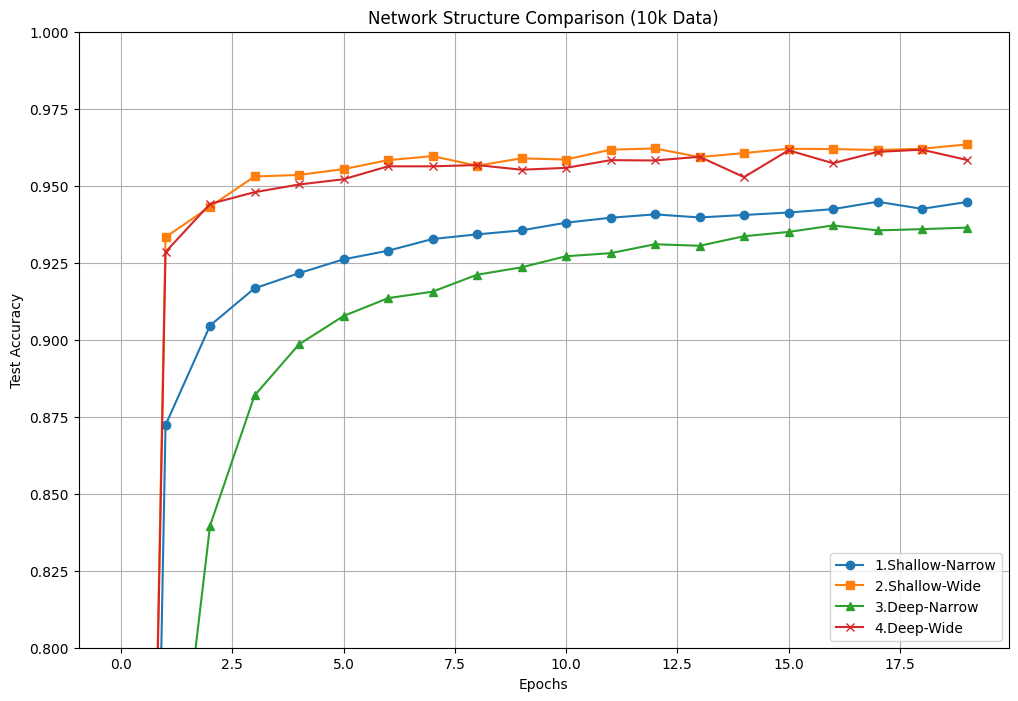

In [6]:
# 4. 결과 시각화
plt.figure(figsize=(12, 8))
markers = {'1.Shallow-Narrow': 'o', '2.Shallow-Wide': 's', '3.Deep-Narrow': '^', '4.Deep-Wide': 'x'}
x = np.arange(len(results_test['1.Shallow-Narrow']))

for key in networks_settings.keys():
    plt.plot(x, results_test[key], marker=markers[key], label=key)

plt.xlabel("Epochs")
plt.ylabel("Test Accuracy")
plt.title("Network Structure Comparison (10k Data)")
plt.ylim(0.8, 1.0)
plt.legend(loc='lower right')
plt.grid()
plt.show()

In [7]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.optim.adam import Adam
from torch.utils.data.dataloader import DataLoader
from torchvision import datasets, transforms

import matplotlib.pyplot as plt
from tqdm import tqdm

100%|██████████| 170M/170M [00:03<00:00, 48.1MB/s]
100%|██████████| 170M/170M [00:03<00:00, 49.4MB/s]


(32, 32, 3)


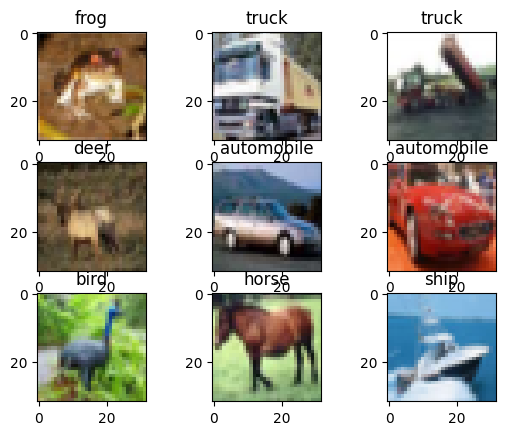

In [10]:
# 데이터셋 정의 -> cifar-10
train_data = datasets.cifar.CIFAR10(
    './data/',
    train=True,
    download=True,
    transform = transforms.Compose([
        transforms.ToPILImage(),
        transforms.RandomHorizontalFlip(0.5),
        transforms.RandomCrop(32, padding=4),
        transforms.ToTensor(),
        transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
    ]))

'''
다음과 같이 정의하여 함수형태로 후처리도 가능합니다

transform=transforms.Compose([
    transforms.ToPILImage(),
    transforms.RandomHorizontalFlip(0.5),
    transforms.RandomCrop(32, padding=4),
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

train_data = data_transform(train_data)
'''


test_data = datasets.cifar.CIFAR10(
    root="../data/",
    train=False,
    download=True,
    transform=transforms.ToTensor())

for i in range(9):
    plt.subplot(3, 3, i+1)
    plt.imshow(train_data.data[i])
    plt.title(train_data.classes[train_data.targets[i]])

print(train_data.data[0].shape)
plt.show()

In [11]:
from torch.utils.data import Dataset

class CustomCIFAR10(Dataset):
    def __init__(self, root, train=True, download=False):
        # self.base_dataset = dataset.load_dataset(path = '')
        self.base_dataset = datasets.cifar.CIFAR10(
            root=root,
            train=train,
            download=download
        )

        self.train = train

        self.transform = transforms.Compose([
            transforms.ToPILImage(),
            transforms.RandomHorizontalFlip(0.5),
            transforms.RandomCrop(32, padding=4),
            transforms.ToTensor(),
            transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
        ])

    def __len__(self):
        return len(self.base_dataset.data)

    def __getitem__(self, idx):
        image = self.base_dataset.data[idx]  # numpy array (H, W, C)
        label = self.base_dataset.targets[idx]

        if self.train:
            image = self.transform(image)

        return image, label

# 인스턴스 생성
train_data = CustomCIFAR10(root='./data/', train=True, download=True)
test_data = CustomCIFAR10(root='./data/', train=False, download=True)

## Modeling

In [12]:
class BasicBlock(nn.Module):
    def __init__(self, in_channels, out_channels, hidden_dim):
        super(BasicBlock, self).__init__()

        self.conv1 = nn.Conv2d(in_channels, hidden_dim, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(hidden_dim, out_channels, kernel_size=3, padding=1)
        self.relu = nn.ReLU()

        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)

        '''
        nn.Sequential 로 각 레이어를 묶어서 하나의 모델로 정의할 수도 있습니다!

        self.model = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=3, stride=1, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),
            nn.Conv2d(32, 64, kernel_size=3, stride=1, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),
            nn.Flatten(),
            nn.Linear(64 * 7 * 7, 128),
            nn.ReLU(),
            nn.Linear(128, 10)
        )
        '''

    def forward(self, x):
        x = self.conv1(x)
        x = self.relu(x)
        x = self.conv2(x)
        x = self.relu(x)
        x = self.pool(x)
        return x

        # return self.model(x)

In [13]:
class CNN(nn.Module):
    def __init__(self, num_classes): # 클래스의 갯수
        super(CNN, self).__init__()

        # CNN 블럭 정의
        self.block1 = BasicBlock(in_channels=3, out_channels=32, hidden_dim=16)
        self.block2 = BasicBlock(in_channels=32, out_channels=128, hidden_dim=64)
        self.block3 = BasicBlock(in_channels=128, out_channels=256, hidden_dim=128)

        # classification을 위한 FC 정의
        self.fc1 = nn.Linear(in_features=4096, out_features=2048)
        self.fc2 = nn.Linear(in_features=2048, out_features=256)
        self.fc3 = nn.Linear(in_features=256, out_features=num_classes)

        self.relu = nn.ReLU()

    def forward(self, x):
        x = self.block1(x)
        x = self.block2(x)
        x = self.block3(x) # 출력모양: (-1, 256, 4, 4)
        x = torch.flatten(x, start_dim=1) # 2차원의 feature map을 1차원으로

        x = self.fc1(x)
        x = self.relu(x)
        x = self.fc2(x)
        x = self.relu(x)
        x = self.fc3(x)

        return x

In [14]:
from torch.utils.data.dataloader import DataLoader

from torch.optim.adam import Adam


# 데이터로더 정의
train_loader = DataLoader(train_data, batch_size=64, shuffle=True)
test_loader = DataLoader(test_data, batch_size=64, shuffle=False)

# 학습을 진행할 프로세서 설정
device = "cuda" if torch.cuda.is_available() else "cpu"


print(f"device 정보: {device}")

# CNN 모델 정의
model = CNN(num_classes=10)

# 모델을 device로 보냄
model.to(device)

device 정보: cpu


CNN(
  (block1): BasicBlock(
    (conv1): Conv2d(3, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (conv2): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (relu): ReLU()
    (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (block2): BasicBlock(
    (conv1): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (conv2): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (relu): ReLU()
    (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (block3): BasicBlock(
    (conv1): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (conv2): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (relu): ReLU()
    (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (fc1): Linear(in_features=4096, out_features=2048, bias=True)
  (fc2): Linear(in_features=2048, out_features=256,

In [ ]:
# Learning rate
lr = 1e-3

# Optimizer
optim = Adam(model.parameters(), lr=lr)

# Train loop
for epoch in range(100):
    for data, label in tqdm(train_loader): # read data
        optim.zero_grad() # Iniitlaization

        preds = model(data.to(device)) # prediction

        # Loss Function
        loss = nn.CrossEntropyLoss()(preds, label.to(device))
        loss.backward()
        optim.step()

    if epoch==0 or epoch%10==9: # 10번마다 손실 출력
        print(f"epoch{epoch+1} loss:{loss.item()}")

# 모델 저장
torch.save(model.state_dict(), "CIFAR.pth")

In [ ]:
model.load_state_dict(torch.load("CIFAR.pth", map_location=device))

num_corr = 0

with torch.no_grad():
    for data, label in tqdm(test_loader):
        output = model(data.to(device))
        preds = output.data.max(1)[1]
        corr = preds.eq(label.to(device).data).sum().item()
        num_corr += corr

    print(f"Accuracy:{num_corr/len(test_data)}")